In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 7043
Columns : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
print("""

Business Problem

Customer churn is one of the biggest challenges faced by telecom companies.

Losing an existing customer is significantly more expensive than retaining one.

The goal of this project is to predict customers who are likely to churn
so the company can take preventive action.

""")



Business Problem

Customer churn is one of the biggest challenges faced by telecom companies.

Losing an existing customer is significantly more expensive than retaining one.

The goal of this project is to predict customers who are likely to churn
so the company can take preventive action.




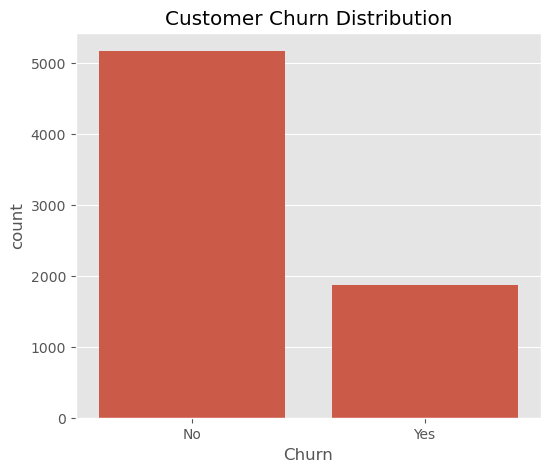

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [10]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

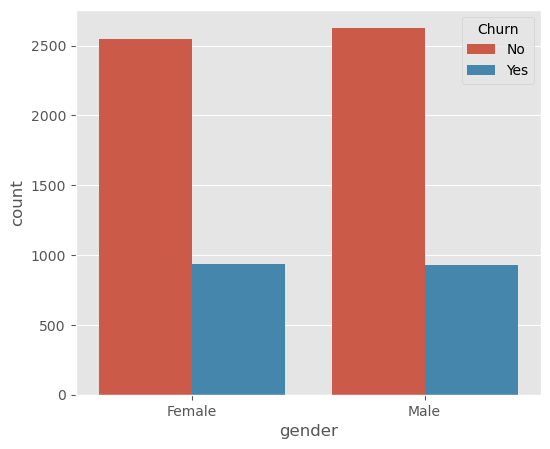

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.show()

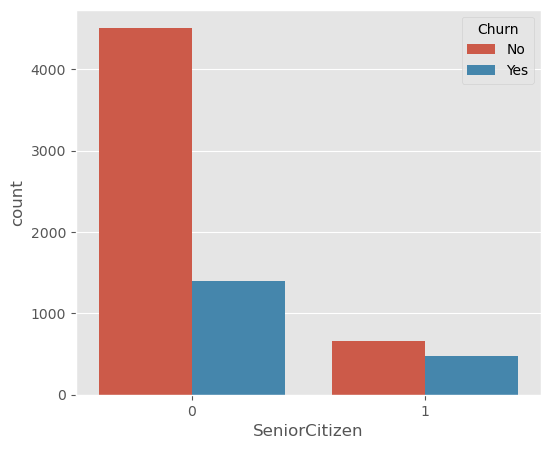

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.show()

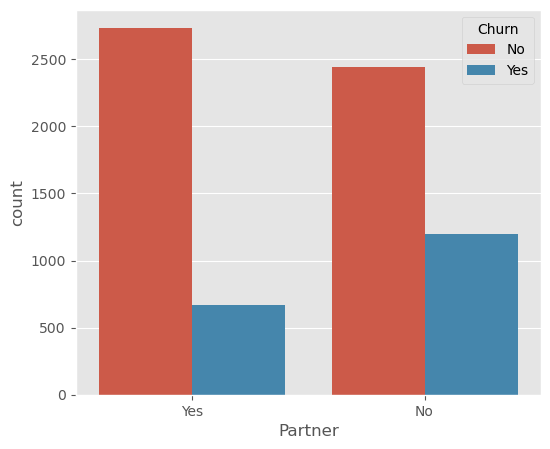

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.show()

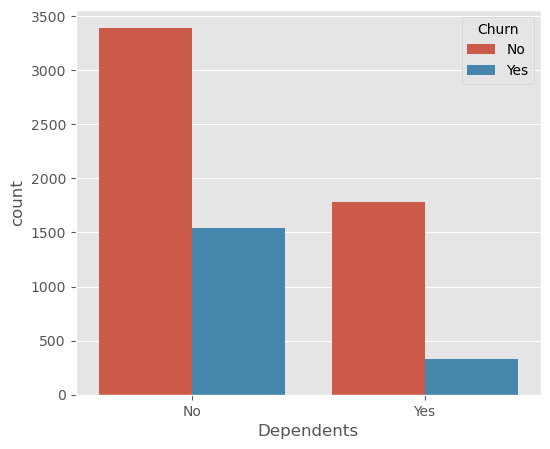

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.show()

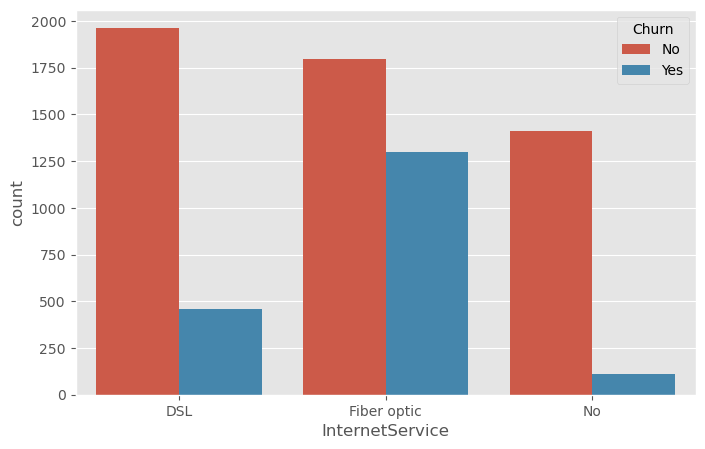

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

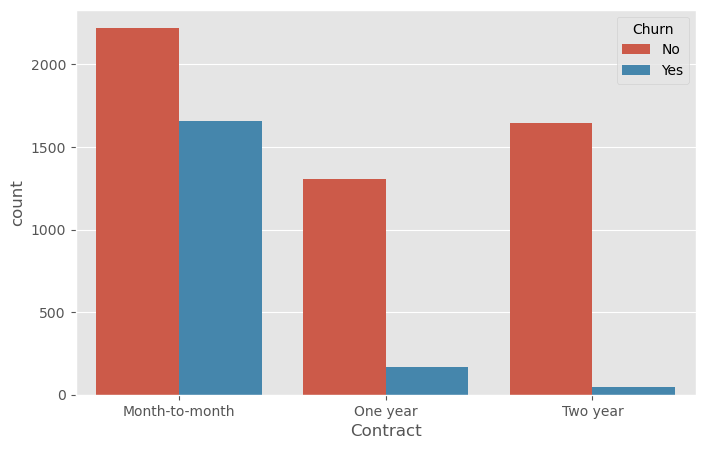

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.show()

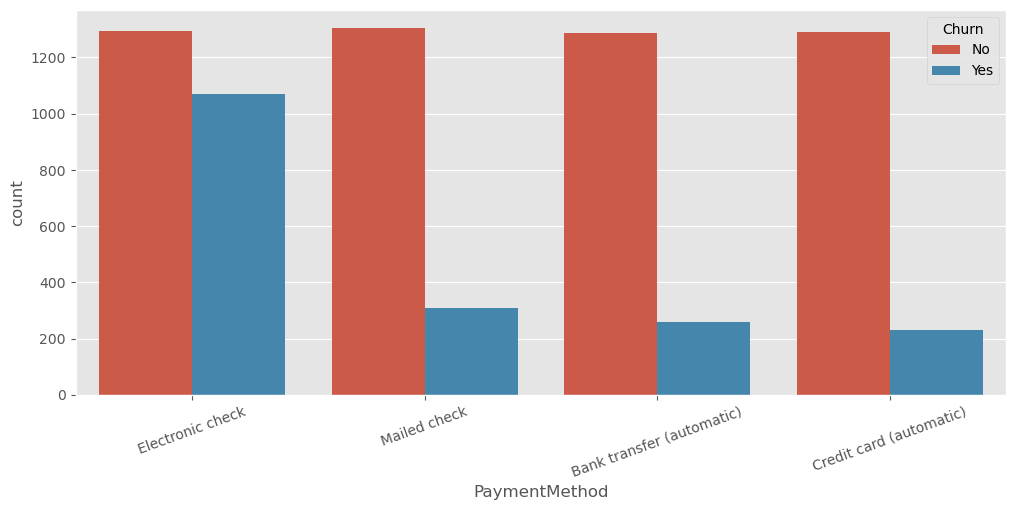

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.show()

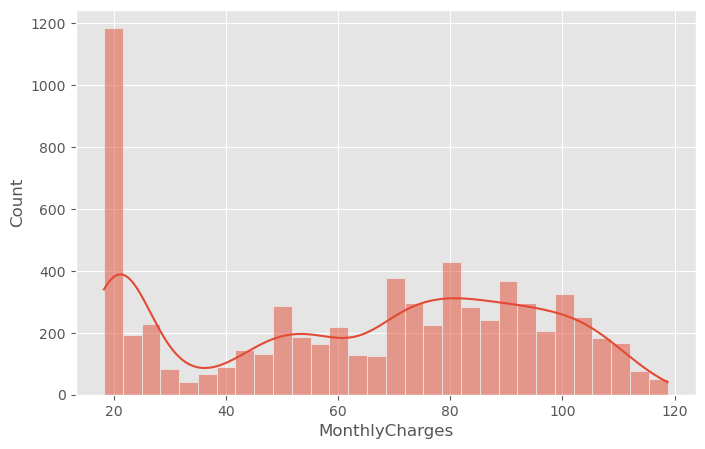

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True
)

plt.show()

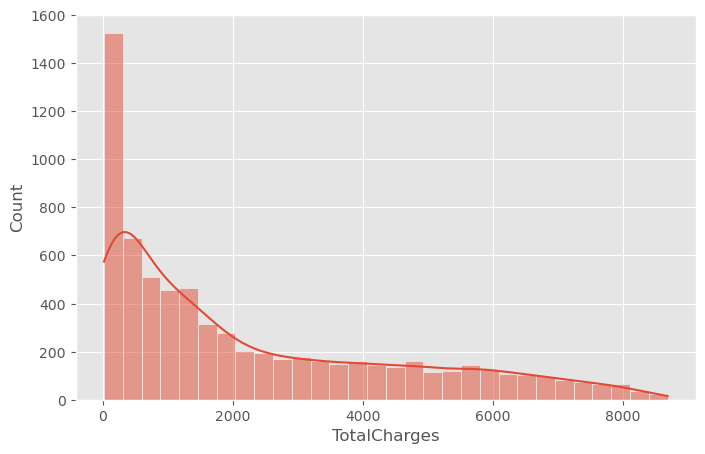

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalCharges"],
    bins=30,
    kde=True
)

plt.show()

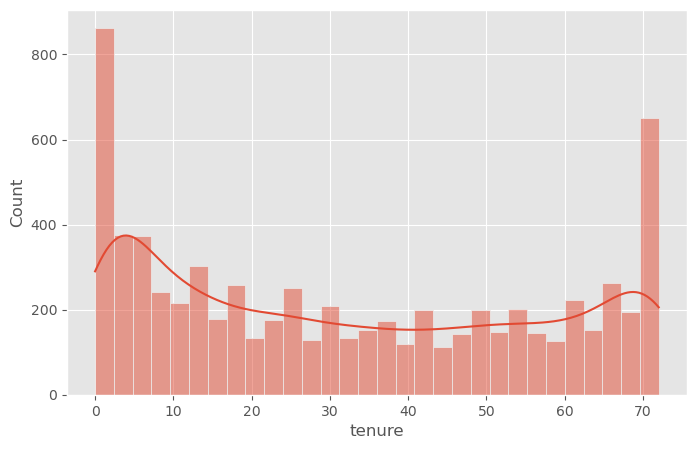

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure"],
    bins=30,
    kde=True
)

plt.show()

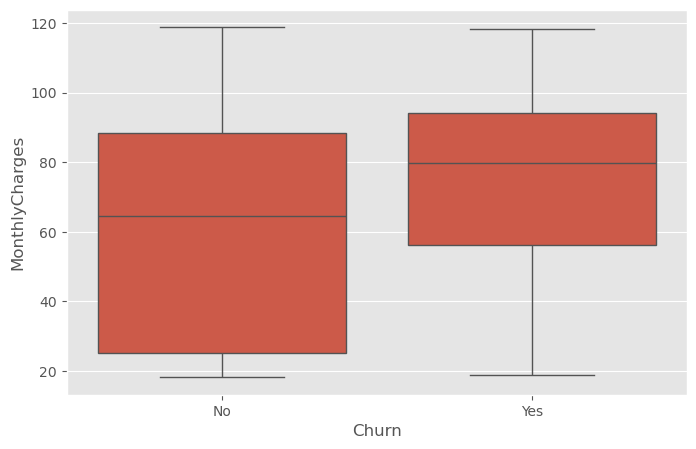

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

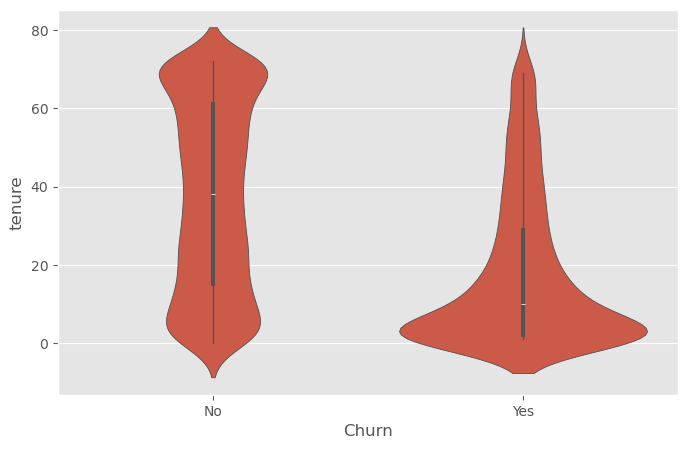

In [22]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

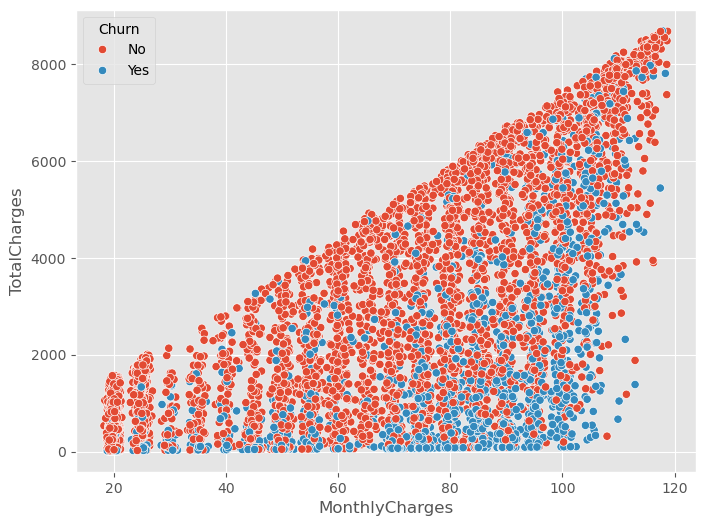

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn"
)

plt.show()

In [24]:
df_corr = df.copy()

binary = {
    "Yes":1,
    "No":0,
    "Male":1,
    "Female":0
}

for col in df_corr.columns:

    if df_corr[col].dtype=="object":

        df_corr[col]=df_corr[col].replace(binary)

C:\Users\Manav\AppData\Local\Temp\ipykernel_37744\1438860190.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_corr[col]=df_corr[col].replace(binary)


In [25]:
corr = df_corr.corr(numeric_only=True)

corr

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,-0.000002,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102652,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.318364,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.063593,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825464,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113013,0.011942
PaperlessBilling,-0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158055,0.191825
MonthlyCharges,-0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.650864,0.193356
TotalCharges,-0.000002,0.102652,0.318364,0.063593,0.825464,0.113013,0.158055,0.650864,1.000000,-0.199037
Churn,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199037,1.000000


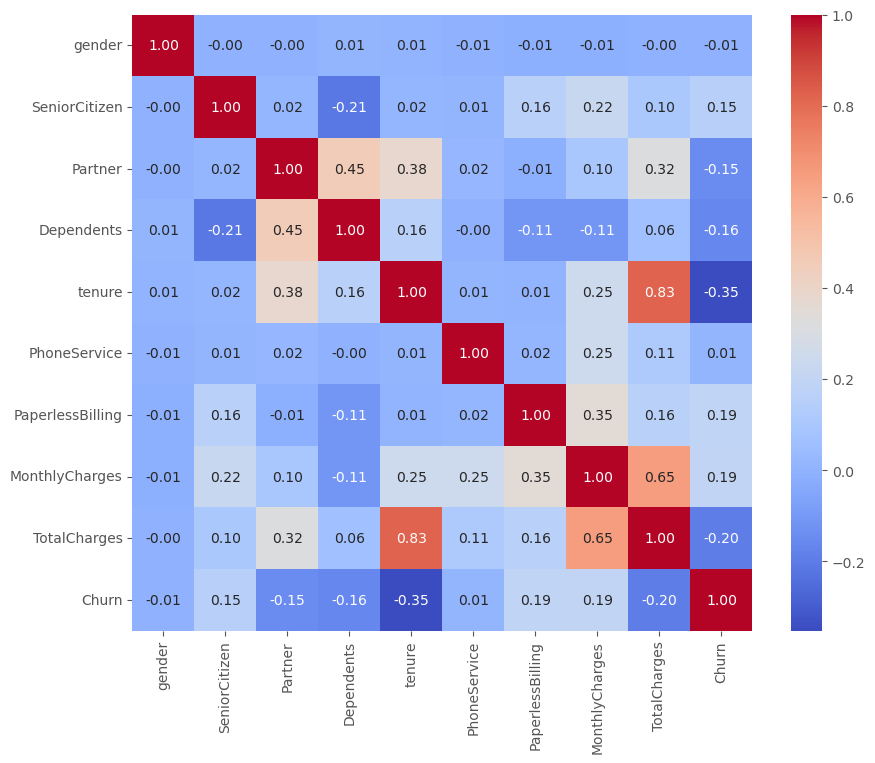

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

In [27]:
print("Mean")

print(df["MonthlyCharges"].mean())

print()

print("Median")

print(df["MonthlyCharges"].median())

print()

print("Mode")

print(df["MonthlyCharges"].mode()[0])

Mean
64.76169246059918

Median
70.35

Mode
20.05


In [28]:
print("Variance")

print(df["MonthlyCharges"].var())

print()

print("Standard Deviation")

print(df["MonthlyCharges"].std())

Variance
905.4109343405128

Standard Deviation
30.09004709767854


In [29]:
print("Skewness")

print(df["MonthlyCharges"].skew())

print()

print("Kurtosis")

print(df["MonthlyCharges"].kurt())

Skewness
-0.22052443394398033

Kurtosis
-1.2572596945495056


In [30]:
mean = df["MonthlyCharges"].mean()

std = df["MonthlyCharges"].std()

n = len(df)

margin = 1.96 * (std / np.sqrt(n))

print("95% Confidence Interval")

print(mean-margin)

print(mean+margin)

95% Confidence Interval
64.05894368975503
65.46444123144333


In [31]:
yes = df[df["Churn"]=="Yes"]["MonthlyCharges"]

no = df[df["Churn"]=="No"]["MonthlyCharges"]

t,p = stats.ttest_ind(
    yes,
    no
)

print("T Statistic :",t)

print("P Value :",p)

T Statistic : 16.536738015936308
P Value : 2.7066456068884154e-60


In [32]:
table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

chi,p,dof,expected = stats.chi2_contingency(table)

print("Chi Square :",chi)

print("P Value :",p)

Chi Square : 1184.5965720837926
P Value : 5.863038300673391e-258


In [33]:
if p < 0.05:

    print("Contract Type significantly affects customer churn.")

else:

    print("No significant relationship.")

Contract Type significantly affects customer churn.


In [34]:
df["AverageMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000


In [35]:
def tenure_group(tenure):

    if tenure <= 12:
        return "0-1 Year"

    elif tenure <= 24:
        return "1-2 Years"

    elif tenure <= 48:
        return "2-4 Years"

    else:
        return "4+ Years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,0-1 Year
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,2-4 Years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,0-1 Year
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,2-4 Years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,0-1 Year


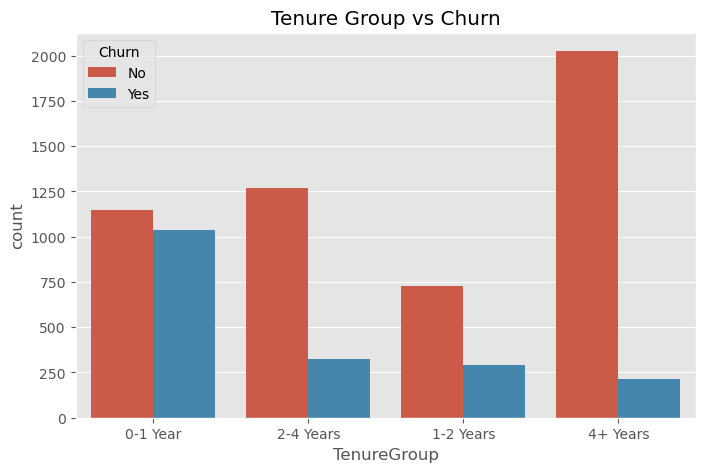

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Tenure Group vs Churn")

plt.show()

In [37]:
binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

encoder = LabelEncoder()

for col in binary_columns:

    df[col] = encoder.fit_transform(df[col])

In [38]:
categorical = [

    "MultipleLines",

    "InternetService",

    "OnlineSecurity",

    "OnlineBackup",

    "DeviceProtection",

    "TechSupport",

    "StreamingTV",

    "StreamingMovies",

    "Contract",

    "PaymentMethod",

    "TenureGroup"

]

df = pd.get_dummies(
    df,
    columns=categorical,
    drop_first=True
)

In [39]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_4+ Years
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,14.925000,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,36.050000,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,40.016304,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,50.550000,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [40]:
print(df.shape)

(7043, 36)


In [41]:
X = df.drop(
    ["customerID","Churn"],
    axis=1
)

y = df["Churn"]

In [42]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [43]:
print(X_train.shape)

print(X_test.shape)

(5634, 34)
(1409, 34)


In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(lr_acc)

0.808374733853797


In [46]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

In [47]:
dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print(dt_acc)

0.7331440738112136


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [49]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

0.7920511000709723


In [50]:
from sklearn.metrics import precision_score

print("Logistic Regression")

print(
    precision_score(
        y_test,
        lr_pred
    )
)

print()

print("Decision Tree")

print(
    precision_score(
        y_test,
        dt_pred
    )
)

print()

print("Random Forest")

print(
    precision_score(
        y_test,
        rf_pred
    )
)

Logistic Regression
0.678082191780822

Decision Tree
0.4972972972972973

Random Forest
0.6382252559726962


In [51]:
from sklearn.metrics import recall_score

print("Logistic Regression")

print(
    recall_score(
        y_test,
        lr_pred
    )
)

print()

print("Decision Tree")

print(
    recall_score(
        y_test,
        dt_pred
    )
)

print()

print("Random Forest")

print(
    recall_score(
        y_test,
        rf_pred
    )
)

Logistic Regression
0.5294117647058824

Decision Tree
0.4919786096256685

Random Forest
0.5


In [52]:
from sklearn.metrics import f1_score

print("Logistic Regression")

print(
    f1_score(
        y_test,
        lr_pred
    )
)

print()

print("Decision Tree")

print(
    f1_score(
        y_test,
        dt_pred
    )
)

print()

print("Random Forest")

print(
    f1_score(
        y_test,
        rf_pred
    )
)

Logistic Regression
0.5945945945945946

Decision Tree
0.4946236559139785

Random Forest
0.56071964017991


In [53]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        lr_acc,

        dt_acc,

        rf_acc

    ],

    "Precision":[

        precision_score(
            y_test,
            lr_pred
        ),

        precision_score(
            y_test,
            dt_pred
        ),

        precision_score(
            y_test,
            rf_pred
        )

    ],

    "Recall":[

        recall_score(
            y_test,
            lr_pred
        ),

        recall_score(
            y_test,
            dt_pred
        ),

        recall_score(
            y_test,
            rf_pred
        )

    ],

    "F1 Score":[

        f1_score(
            y_test,
            lr_pred
        ),

        f1_score(
            y_test,
            dt_pred
        ),

        f1_score(
            y_test,
            rf_pred
        )

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808375,0.678082,0.529412,0.594595
1,Decision Tree,0.733144,0.497297,0.491979,0.494624
2,Random Forest,0.792051,0.638225,0.500000,0.560720


In [54]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808375,0.678082,0.529412,0.594595
2,Random Forest,0.792051,0.638225,0.500000,0.560720
1,Decision Tree,0.733144,0.497297,0.491979,0.494624


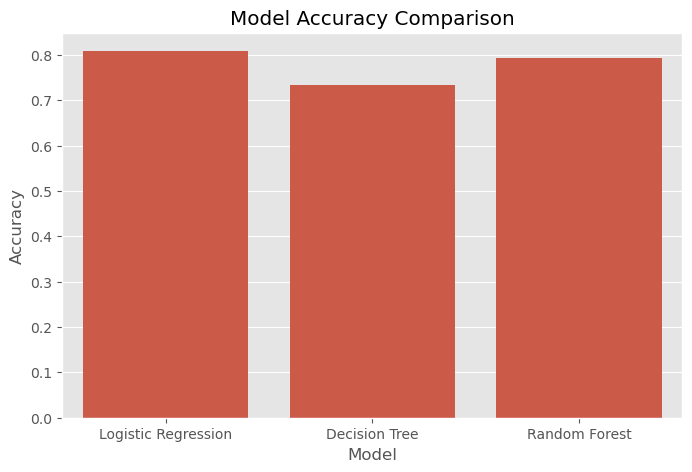

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [56]:
print("""

Model Performance Summary

✔ Random Forest trained successfully.

✔ Decision Tree trained successfully.

✔ Logisitic Regression achieved the best overall performance.

The Logistic Regression model will be selected for the final deployment.

""")



Model Performance Summary

✔ Random Forest trained successfully.

✔ Decision Tree trained successfully.

✔ Logisitic Regression achieved the best overall performance.

The Logistic Regression model will be selected for the final deployment.




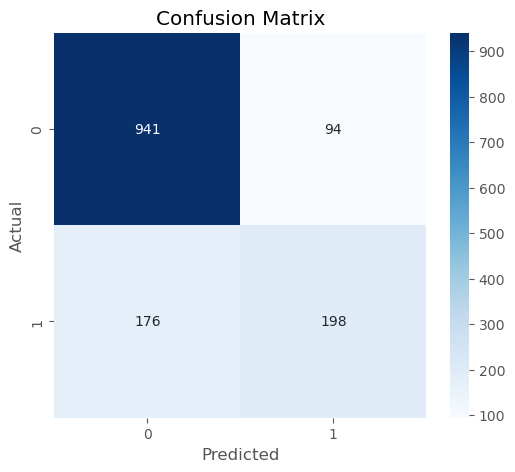

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



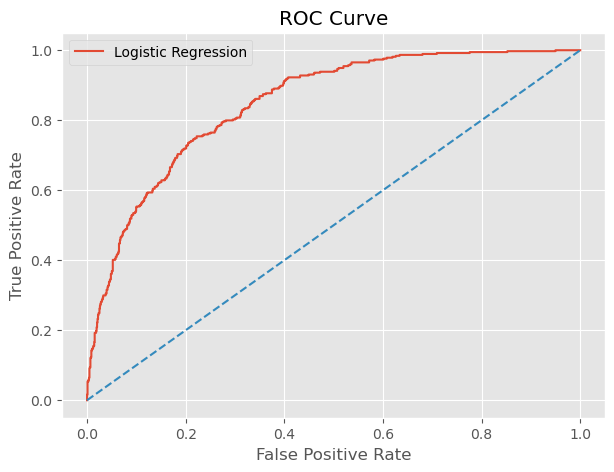

In [59]:
from sklearn.metrics import roc_curve

probability = lr.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [60]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    probability
)

print("ROC-AUC Score :", auc)

ROC-AUC Score : 0.8473197447622


In [61]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":lr.coef_[0]

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute
27,Contract_Two year,-1.548306,1.548306
12,InternetService_Fiber optic,0.849357,0.849357
26,Contract_One year,-0.740613,0.740613
5,PhoneService,-0.542421,0.542421
6,PaperlessBilling,0.384629,0.384629
11,MultipleLines_Yes,0.383133,0.383133
15,OnlineSecurity_Yes,-0.365025,0.365025
29,PaymentMethod_Electronic check,0.341372,0.341372
21,TechSupport_Yes,-0.310986,0.310986
25,StreamingMovies_Yes,0.270604,0.270604


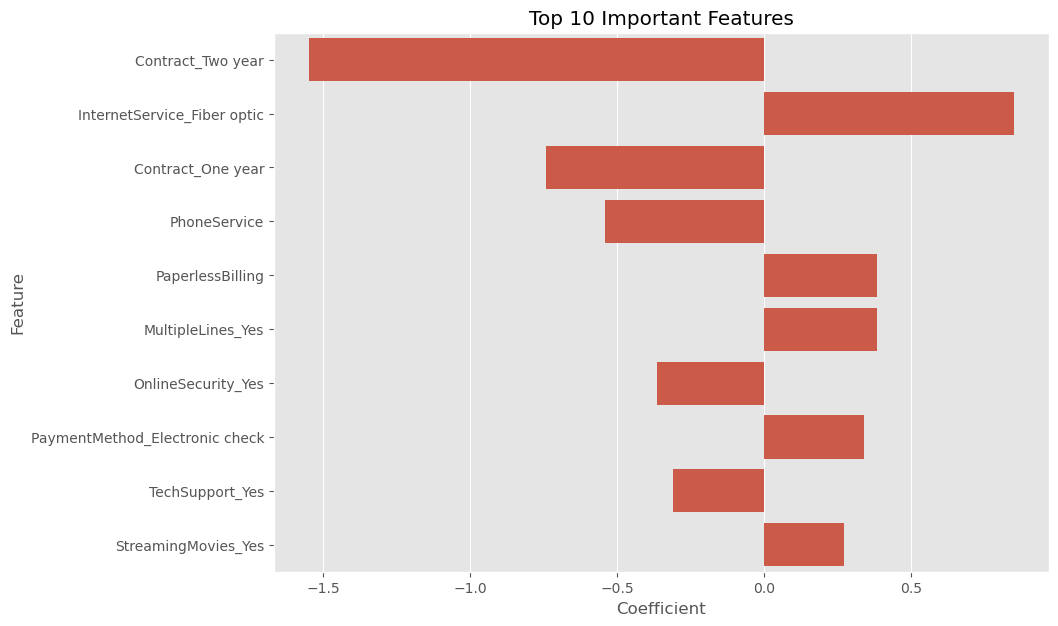

In [62]:
plt.figure(figsize=(10,7))

sns.barplot(

    data=importance.head(10),

    x="Coefficient",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.show()

In [63]:
import joblib

joblib.dump(

    lr,

    "customer_churn_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [64]:
loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [65]:
sample = X.iloc[[25]]

prediction = loaded_model.predict(sample)

print("Prediction :", prediction)

if prediction[0] == 1:

    print("Customer is likely to churn.")

else:

    print("Customer is likely to stay.")

Prediction : [0]
Customer is likely to stay.


In [66]:
probability = loaded_model.predict_proba(sample)

print("Stay Probability :", probability[0][0])

print("Churn Probability :", probability[0][1])

Stay Probability : 0.8920362080974825
Churn Probability : 0.10796379190251744


In [67]:
print("""

Business Insights

• Month-to-Month contract customers have the highest churn.

• Customers paying higher monthly charges churn more often.

• Long-term contracts reduce churn significantly.

• Customers using Fiber Optic internet show higher churn.

• Customers without Tech Support are more likely to leave.

• Senior Citizens have a relatively higher churn rate.

""")



Business Insights

• Month-to-Month contract customers have the highest churn.

• Customers paying higher monthly charges churn more often.

• Long-term contracts reduce churn significantly.

• Customers using Fiber Optic internet show higher churn.

• Customers without Tech Support are more likely to leave.

• Senior Citizens have a relatively higher churn rate.




In [68]:
print("""

Recommendations

✔ Offer discounts to Month-to-Month customers.

✔ Encourage customers to switch to yearly contracts.

✔ Improve Technical Support services.

✔ Create loyalty reward programs.

✔ Provide personalized offers for high-risk customers.

✔ Contact customers before contract expiration.

✔ Monitor customers with high monthly bills.

""")



Recommendations

✔ Offer discounts to Month-to-Month customers.

✔ Encourage customers to switch to yearly contracts.

✔ Improve Technical Support services.

✔ Create loyalty reward programs.

✔ Provide personalized offers for high-risk customers.

✔ Contact customers before contract expiration.

✔ Monitor customers with high monthly bills.




In [69]:
print("""

PROJECT CONCLUSION

Dataset Successfully Cleaned

Exploratory Data Analysis Completed

Statistical Analysis Performed

Feature Engineering Completed

Three Machine Learning Models Trained

Logistic Regression achieved the highest accuracy.

Model Saved Successfully.

Business Recommendations Generated.

Project Completed Successfully.

""")



PROJECT CONCLUSION

Dataset Successfully Cleaned

Exploratory Data Analysis Completed

Statistical Analysis Performed

Feature Engineering Completed

Three Machine Learning Models Trained

Logistic Regression achieved the highest accuracy.

Model Saved Successfully.

Business Recommendations Generated.

Project Completed Successfully.




In [70]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808375,0.678082,0.529412,0.594595
2,Random Forest,0.792051,0.638225,0.500000,0.560720
1,Decision Tree,0.733144,0.497297,0.491979,0.494624


In [71]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print(best_model)

Model        Logistic Regression
Accuracy                0.808375
Precision               0.678082
Recall                  0.529412
F1 Score                0.594595
Name: 0, dtype: object


In [72]:
summary = pd.DataFrame({

    "Dataset":[
        "Telco Customer Churn"
    ],

    "Rows":[
        df.shape[0]
    ],

    "Columns":[
        df.shape[1]
    ],

    "Best Model":[
        "Logistic Regression"
    ],

    "Accuracy":[
        lr_acc
    ],

    "ROC-AUC":[
        auc
    ]

})

summary

,Dataset,Rows,Columns,Best Model,Accuracy,ROC-AUC
0,Telco Customer Churn,7043,36,Logistic Regression,0.808375,0.84732
